## Part 1

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import re
from nltk.corpus import stopwords
import nltk
import Stemmer
from tqdm.notebook import tqdm
nltk.download('stopwords', quiet=True)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
import gc
from collections import Counter
from sklearn.metrics import confusion_matrix
from transformers import (
    AlbertTokenizer,
    AlbertForSequenceClassification,
    DataCollatorWithPadding
)
import torch

In [ ]:
# Import small test dataset (for checking that the functions work)
url = "https://raw.githubusercontent.com/several27/FakeNewsCorpus/master/news_sample.csv"
df = pd.read_csv(url)

In [2]:
# Define regex patterns to use for tokenization:

# URLs
URL_RE = re.compile(
    r'https?://[^\s<>"{}|\\^`\[\]]+'  
    r'|www\.[^\s<>"{}|\\^`\[\]]+'     
    r'|\b[a-zA-Z0-9.-]+\.[a-z]{2,}'   
    r'(?:/[^\s]*)?',                   
    re.IGNORECASE
)

# Dates
DATE_RE = re.compile(
    r'\b\d{1,4}[-/\.]\d{1,2}[-/\.]\d{1,4}\b' 
    r'|\b(?:Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)[a-z]*'  
    r'\.?\s+\d{1,2}(?:st|nd|rd|th)?'           
    r'(?:,?\s+\d{2,4})?\b'                      
    r'|\b\d{1,2}(?:st|nd|rd|th)?\s+'            
    r'(?:Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)[a-z]*'
    r'(?:,?\s+\d{2,4})?\b',
    re.IGNORECASE
)
# Numbers
NUM_RE = re.compile(r'\b\d+\b')

# Words + special tokens.
TOKENS = re.compile(r'<[^>]+>|[a-z]+')


# Get stopword list and stemmer.
stop_words = set(stopwords.words('english'))

stemmer = Stemmer.Stemmer('english')

In [ ]:
def preprocessing(df):

    # Initialize vocabularies
    vocab_before  = set()
    vocab_no_stop = set()
    vocab_stemmed = set()
    tokenized = []
    non_eng_articles = 0

    # Go through each row (with progress bar)
    for text in tqdm(df["content"], desc="Preprocessing", mininterval=1.0):

        # Make all text lower case
        text = text.lower()

        # Switch out URLs, dates and numbers with special tokens
        text = URL_RE.sub(" <URL> ", text)
        text = DATE_RE.sub(" <DATE> ", text)
        text = NUM_RE.sub(" <NUM> ", text)

        # Make a list of tokens in the text
        tokens_before  = TOKENS.findall(text)

        tokens_non_eng = NON_ENG.findall(text)
        if len(tokens_non_eng) > 20:
            non_eng_articles += 1


        # Remove stop words
        tokens_no_stop = [t for t in tokens_before if t not in stop_words]

        # Stem the tokens
        tokens_stemmed = stemmer.stemWords(tokens_no_stop)



        # Save the vocabularies at each step
        vocab_before.update(tokens_before)
        vocab_no_stop.update(tokens_no_stop)
        vocab_stemmed.update(tokens_stemmed)
        tokenized.append(tokens_stemmed)

    # Save results in the dataframe
    df["tokenized"] = tokenized

    # Print out relevant measures
    print(f'Vocabulary size before preprocessing: {len(vocab_before)}\n')
    for t, vocab in (('After removing stopwords', vocab_no_stop), ('After stemming', vocab_stemmed)):
        print(f'######## {t} ########')
        print(f"Vocabulary size: {len(vocab)}")
        print(f'Reduction rate: {1 - (len(vocab)/len(vocab_before))}\n')

    print(f'Number of non-english articles {non_eng_articles}')
    return df

In [2]:
# Mikkel
def data_split(X, y, train_frac = 0.8, test_frac = 0.1, val_frac = 0.1, stratify=None, seed=None):
    '''
    Splits the data into a training, testing and validation set. The size fraction of each set
    can be specified.

    Returns a tuple containing features (X) and targets (y) for all sets.
    '''

    # Split the dataset into training and other (test + val) set.
    X_train, X_other, y_train, y_other = train_test_split(X, y, test_size=(1-train_frac), stratify=stratify, random_state=seed)

    # Split other into test and val set.
    X_test, X_val, y_test, y_val = train_test_split(X_other, y_other, test_size=(val_frac/(test_frac+val_frac)), stratify=stratify, random_state=seed)

    return (X_train, X_test, X_val, y_train, y_test, y_val)

In [ ]:
# Process small test set
df = preprocessing(df)


In [5]:
# Download data from huggingface repositiory (we uploaded the data first).
from huggingface_hub import hf_hub_download

file_path = hf_hub_download(
    repo_id="MikkelPraestegaard/GDS_final_assignment",
    filename="subset_FakeNews.zip",
    repo_type="dataset",
)

In [ ]:
# Read in the data
df1 = pd.read_csv(file_path)

# Remove the single row with NaN in content
df1 = df1.dropna(subset=['content'])

/tmp/ipykernel_50252/1746058972.py:2: DtypeWarning: Columns (0,1) have mixed types. Specify dtype option on import or set low_memory=False.
  df1 = pd.read_csv(file_path)


In [30]:
grouped_domain = df1[['type', 'domain']].groupby(by='domain')

c = 0
for i, v in grouped_domain:
    if len(v['type'].unique()) > 1:
        print('This domain has more then one type')
    else:
        c +=1

if c == len(grouped_domain):
    print('All domains have only 1 unique type attached to them')
else:
    print(f'{len(df1) - c} have more than 1 unique type')

del grouped_domain

All domains have only 1 unique type attached to them


In [ ]:
# Remove rows with ambiguous True or False type (eg. satire). ~ is the not operation.
ambiguous = ['unknown', 'nan', 'political', 'clickbait', '2018-02-10 13:43:39.521661']
ambig_mask = ~df1['type'].isin(ambiguous)
df1 = df1.loc[ambig_mask, :]

# Create new column for True or Fake labels. True will be labeled 0/False and fake will be labels 1/True.
true_list = ['reliable']
df1['target'] = ~df1['type'].isin(true_list)

In [7]:
df1 = preprocessing(df1)

gc.collect()

Preprocessing:   0%|          | 0/729523 [00:00<?, ?it/s]

Vocabulary size before preprocessing: 796367

######## After removing stopwords ########
Vocabulary size: 796214
Reduction rate: 0.00019212247619504463

######## After stemming ########
Vocabulary size: 657270
Reduction rate: 0.17466444491044963



16

In [ ]:
df2 = pd.read_csv(r"C:\Users\miche\Bioinformatik_studium\2_year\GDS\dataset_liar\test.tsv", encoding= 'utf-8', sep = "\t")

print(df2.head())


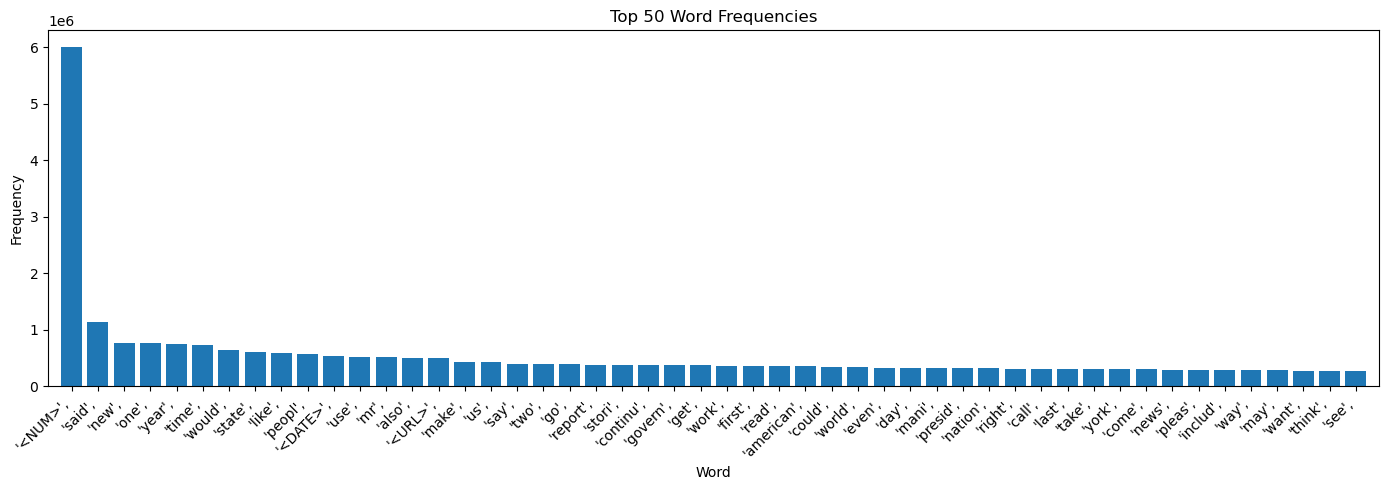

In [45]:
def wordcount(data):
    counter = Counter()

    for doc in data:
        if isinstance(doc, str):
            tokens = doc.split()
        else:
            tokens = doc
        
        counter.update(tokens)

    return counter


def visualize_top_words(
    data,              # iterable of token lists or strings
    top_n: int = 10_000,
    loglog: bool = True
):
    """
    data     : iterable of tokenized text (list of tokens per document) 
    top_n    : number of most frequent words to visualize
    loglog   : whether to use a log-log scale
    """
    label_limit = 100

    # Count words using Counter
    counter = wordcount(data)

    # Get the top_n words and their counts
    top_counts = counter.most_common(top_n)
    words, freqs = zip(*top_counts)  # separate words and counts

    # Plot
    plt.figure(figsize=(14, 5))

    if loglog:
        ranks = np.arange(1, len(freqs) + 1)
        plt.loglog(ranks, freqs)
        plt.xlabel("Rank")
        plt.ylabel("Frequency")
        plt.title("Word Frequency (Log-Log Scale)")
    else:
        if top_n <= label_limit:
            ranks = np.arange(len(words))
            plt.bar(words, freqs, align='center')
            plt.xticks(ranks, words, rotation=45, ha='right')
            plt.xlabel("Word")
        else:
            plt.plot(freqs)
            plt.xlabel("Rank")
        plt.ylabel("Frequency")
        plt.title(f"Top {len(freqs)} Word Frequencies")

    plt.margins(x=0.01)
    plt.tight_layout()
    plt.show()

    return

visualize_top_words(df1['tokenized'], 50, loglog=False)

In [10]:
def prepare_dataset(data, complex_model = False):
    
    counter = wordcount(data)
    vocab = [word for word, _ in counter.most_common(10000)]
    if complex_model:
        vectorizer = TfidfVectorizer(vocabulary=vocab, tokenizer=lambda x: x, lowercase=False)
    else:
        vectorizer = CountVectorizer(vocabulary=vocab, tokenizer=lambda x: x, lowercase=False)
    counts = vectorizer.transform(data)

    return counts


In [3]:
df1 = pd.read_csv("Data/preprocessed.csv")

In [ ]:
seed = 123

features = df1['tokenized']
labels = df1['target']

features_logistic = prepare_dataset(features)

X_train, X_test, X_val, y_train, y_test, y_val = data_split(features_logistic, labels, seed=seed)

In [47]:
label_dists = {'Full Dataset': df1['target'].value_counts()/len(df1),
               'Training data': y_train.value_counts()/len(y_train),
               'Validation data': y_val.value_counts()/len(y_val),
               'Test data': y_test.value_counts()/len(y_test)}

label_dists = pd.DataFrame(label_dists)
label_dists

,Full Dataset,Training data,Validation data,Test data
target,,,,
True,0.700403,0.700623,0.702233,0.696814
False,0.299597,0.299377,0.297767,0.303186


In [ ]:
# Logistic model
logistic = LogisticRegression(max_iter=2000, random_state=seed)

logistic.fit(X_train, y_train)
preds = logistic.predict(X_val)
score = f1_score(y_val, preds)

gc.collect()
del features_logistic

print(f'F1 score of logistic model on validation set: {score}')

preds_liar = logistic.predict(liar)
score_liar = f1_score(liar_true, preds_liar)

F1 score of logistic model: 0.957566083637028


In [ ]:
from sklearn.ensemble import RandomForestClassifier as RanFor

features_RF = prepare_dataset(df['tokenized'], True)

X_train, X_test, X_val, y_train, y_test, y_val = data_split(features_RF, labels, seed=seed)

#model validation to choose optimal hyperparameters

best_val_score = 0
best_parameters = {}

for n_estimators in [10,20,30,40,50,60,70,80,90,100]:
    for max_depth in [None,10,12,14,16,18,20]:
        for max_features in ['sqrt','log2']:
            model = RanFor(
                n_estimators=n_estimators,
                max_depth=max_depth,
                max_features=max_features,
                )
            model.fit(X_train, y_train)
            val_score = model.score(X_val, y_val)
            train_score = model.score(X_train,y_train)

            if val_score > best_val_score:
                best_val_score = val_score
                best_parameters = {
                    'n_estimators': n_estimators,
                    'max_depth': max_depth,
                    'max_features': max_features
                }

print("Best parameters:", best_parameters, "Training accuracy:", train_score, "Validation accuracy:", val_score)


#when figuring out how to do this on big sample without taking an hour, execute the lines below:
FakeNewsForest = RanFor(n_estimators=best_parameters)
FakeNewsForest.fit(X_train,y_train)
rf_preds = FakeNewsForest.predict(X_val)

for i in (X_train, X_test, X_val, y_train, y_test, y_val, features_RF):
    del i

gc.collect()

## Evaluation

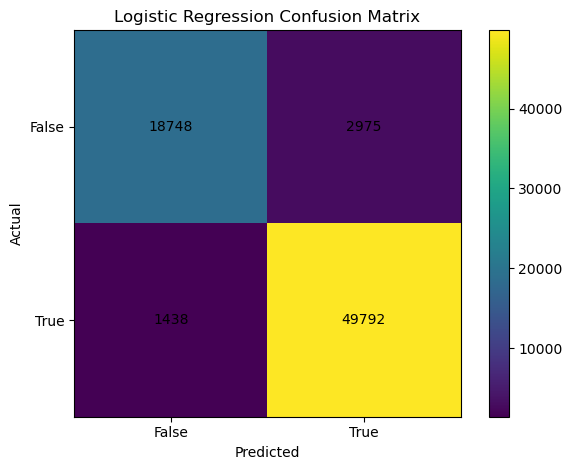

In [12]:
#evaluation of Logistic regression model

#evaluation of Random forest model

#evaluation of Albert transformer

#confusion matrix
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure()
    plt.imshow(cm)
    plt.title(title)
    plt.colorbar()

    labels = np.unique(y_true)
    tick_marks = np.arange(len(labels))

    plt.xticks(tick_marks, labels)
    plt.yticks(tick_marks, labels)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j],
                     ha="center", va="center")

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

#random forest
#plot_cm(y_val, rf_preds, "Random Forest Confusion Matrix")

#logistic regression
plot_cm(y_val, preds, "Logistic Regression Confusion Matrix")



## Import fine tuned ALBERT

In [13]:
from huggingface_hub import snapshot_download

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Download model and create folder "fine_tuned_albert"
snapshot_download(
    repo_id="MikkelPraestegaard/FakeBERT",
    local_dir="./fine_tuned_albert",
    local_dir_use_symlinks=False,
)

tokenizer = AlbertTokenizer.from_pretrained('./fine_tuned_albert')

albert = AlbertForSequenceClassification.from_pretrained('./fine_tuned_albert', num_labels=2)

# Set model to evaluation mode
albert.eval()
albert.to(device)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

X = df1['content']
y = df1['target']

X_train, X_test, X_val, y_train, y_test, y_val = data_split(X, y, seed=seed)

del X_train
del y_train
del df1
gc.collect()


/home/mikkel/miniconda3/lib/python3.13/site-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `snapshot_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/27 [00:00<?, ?it/s]

238

In [14]:
from datasets import Dataset
from torch.utils.data import DataLoader

def tokenize(data):
    return tokenizer(data['content'], truncation=True, padding=True, return_tensors="pt")
    
X_val = Dataset.from_pandas(X_val.to_frame())
X_val = X_val.map(tokenize, batched=True)

X_val = X_val.remove_columns(["content", "__index_level_0__"])


Map:   0%|          | 0/72953 [00:00<?, ? examples/s]

In [16]:
eval_dataloader = DataLoader(X_val, batch_size=64, collate_fn=data_collator)

results = []
for batch in tqdm(eval_dataloader, desc='Predicting labels'):
    batch = {k: v.to(device) for k, v in batch.items()}

    with torch.inference_mode():
        preds = albert(**batch)

    preds = preds.logits
    preds = torch.argmax(preds, dim=-1)

    results.extend(preds.cpu().numpy())

validation_score = f1_score(y_val, results)
print(f"Validation score of ALBERT: {validation_score}")

Predicting labels:   0%|          | 0/1140 [00:00<?, ?it/s]

Validation score of ALBERT: 0.9958968061362728


In [18]:
pd.DataFrame(results).to_csv('Albert_predictions.csv')

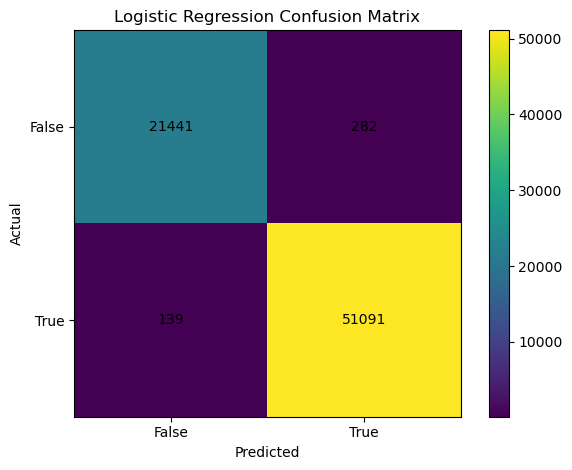

In [19]:
plot_cm(y_val, results, "Logistic Regression Confusion Matrix")